# Starting-Yield-Bond-Decade — the quant teardown 📜

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Works_for_stocks%3F: Busted](https://img.shields.io/badge/Works_for_stocks%3F-Busted-8b949e?style=flat-square)

**Claim (Bogle 1991; Bogle & Nolan 2015; Leibowitz duration-targeting):** the entry 10-year yield explains ~90% of the variance of the subsequent decade's return of a constant-maturity Treasury portfolio — an arithmetic identity, not a forecast.

**Design.** Shiller monthly GS10 1871-01→2023-09 spliced with ^TNX monthly means →2026-06; constant-maturity 10y **nominal** TR roll (Swinkels-2019-style closed-form par-bond pricing); signal = month-*t* average yield, entry = end of month *t* (one documented lag). **Primary unit = the non-overlapping decade** (Valkanov 2003 is why); overlapping windows are secondary with NW(120) HAC. As-of 2026-07-03, last complete month 2026-06, fingerprint `36732503ca4f`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from starting_yield_bond_decade import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_bond_panel()
    DEC = st.decade_table(PANEL, phase=0)
else:
    PANEL = DEC = None
print("real GS10 cache present:", HAVE_REAL,
      "| months:", (0 if PANEL is None else len(PANEL)),
      "| non-overlapping decades:", (0 if DEC is None else len(DEC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'months': 1866, 'start': '1871-01', 'end': '2026-06', 'shiller_months': 1833, 'shiller_end': '2023-09', 'tnx_months': 33, 'n_overlap': 1746, 'fwd_end': '2016-06', 'fingerprint': '36732503ca4f', 'n_dec': 15, 'dec_first': '1871-01', 'dec_last': '2011-01', 'r2': 0.923, 'slope': 1.086, 't_slope': 12.5, 'intercept_pct': -0.34, 't_intercept': -0.72, 't_slope_vs1': 0.99, 'mae_pp': 0.64, 'resid_pp': 0.86, 'ph_r2_min': 0.865, 'ph_r2_med': 0.939, 'ph_r2_max': 0.97, 'ph_t_min': 8.75, 'ph_t_med': 13.89, 'ph_n': 120, 'hac_n': 1746, 'hac_r2': 0.916, 'hac_slope': 1.14, 'hac_t': 32.71, 'hac_lags': 120, 'halves': [('1871-01', '1941-01', 8, 0.908, 1.2, 7.69), ('1943-10', '2013-10', 8, 0.954, 1.3, 11.17)], 'c_start': '2020-12', 'c_y0': 0.93, 'c_years': 5.5, 'c_realized': -2.21, 'c_dd': -22.9, 'c_required': 4.91, 'c_end': '2026-06', 's_n': 14, 's_first': '1881-01', 's_last': '2011-01', 's_r2': 0.205, 's_slope': 0.63, 's_t': 1.76, 's_mae': 4.57, 's_hac_r2': 0.251, 's_hac_t': 3.48, 's_hac_n': 1590, 'rr_n': 15, 'rr_r2': 0.239, 'rr_slope': 0.81, 'rr_t': 2.02, 'spread_bp': 2.0, 'drag_bp_yr': 0.2, 'cost_ratio': 319, 'syn': [(1.0, 0.9, 11.2, 100), (0.5, 0.729, 6.65, 95), (0.0, 0.102, 0.2, 10)]}


real GS10 cache present: True | months: 1866 | non-overlapping decades: 15


## 0 · Tape and engine

1866 months 1871-01 -> 2026-06 (shiller 1833, tnx 33) | fingerprint 36732503ca4f
forward-decade windows: 1746 (1871-01 -> 2016-06)


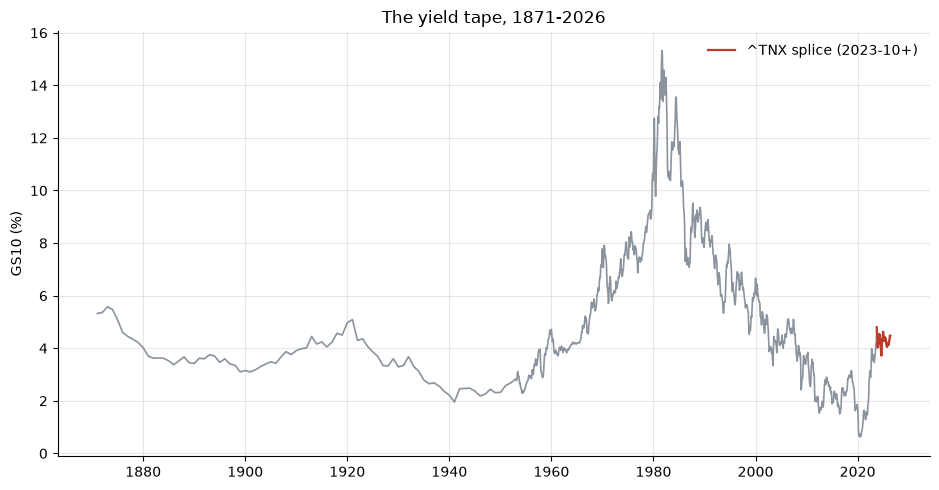

In [2]:
if HAVE_REAL:
    g = data.load_gs10()
    n_sh = int((g['source']=='shiller').sum()); n_tnx = int((g['source']=='tnx').sum())
    print(f'{len(g)} months {g.index.min():%Y-%m} -> {g.index.max():%Y-%m} '
          f'(shiller {n_sh}, tnx {n_tnx}) | fingerprint {data.fingerprint(g)}')
    usable = PANEL.dropna(subset=['fwd10'])
    print(f'forward-decade windows: {len(usable)} ({usable.index.min():%Y-%m} -> {usable.index.max():%Y-%m})')
    fig, ax = plt.subplots()
    ax.plot(g.index, g['gs10']*100, color=GREY, lw=1.2)
    tnx_part = g[g['source']=='tnx']
    ax.plot(tnx_part.index, tnx_part['gs10']*100, color=RED, lw=1.6, label='^TNX splice (2023-10+)')
    ax.set_ylabel('GS10 (%)'); ax.set_title('The yield tape, 1871-2026')
    ax.legend(frameon=False); plt.tight_layout(); plt.show()
else:
    print('cache missing - frozen tape:', R['months'], 'months', R['start'], '->', R['end'])

> 💡 **In plain words.** The return series is *simulated from yields* — each month we "buy" a fresh 10-year par bond and "sell" it a month later at the new yield. Swinkels (2019) validates this construction at ≈0.99 correlation against actual Treasury index returns. The whole claim is that this simulation's decade average is pinned by its first input.

## 1 · Primary — non-overlapping decades (unit = decade)

n = 15 decades (1871-01 ... 2011-01)
R2 = 0.923  slope = +1.086 (t = +12.50)  intercept = -0.34%/yr (t = -0.72)
identity: t(slope=1) = +0.99 | MAE of 'return = yield' = 0.64 pp/yr | resid std 0.86 pp/yr


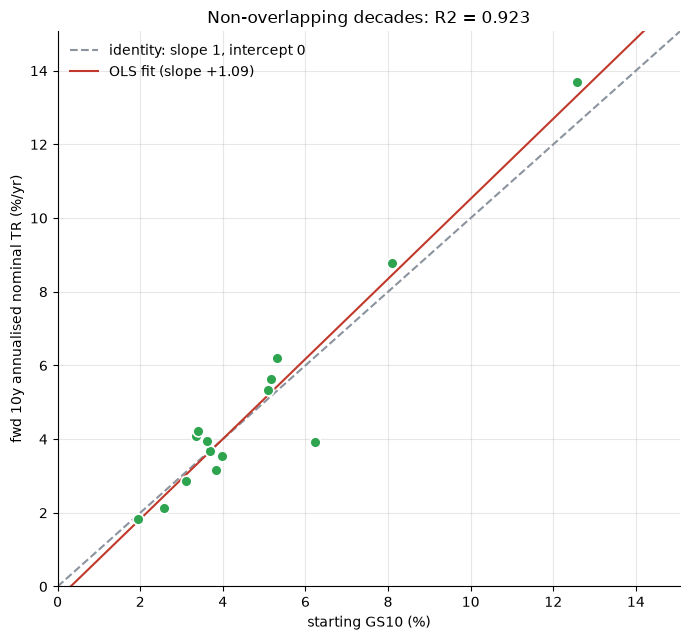

In [3]:
if HAVE_REAL:
    d = st.decade_ols(PANEL, phase=0)
    print(f"n = {d['n']} decades ({d['starts'][0]} ... {d['starts'][-1]})")
    print(f"R2 = {d['r2']:.3f}  slope = {d['slope']:+.3f} (t = {d['t_slope']:+.2f})  "
          f"intercept = {d['intercept']*100:+.2f}%/yr (t = {d['t_intercept']:+.2f})")
    print(f"identity: t(slope=1) = {d['t_slope_vs1']:+.2f} | MAE of 'return = yield' = "
          f"{d['mae_identity']*100:.2f} pp/yr | resid std {d['resid_std']*100:.2f} pp/yr")
    x, y = DEC['gs10']*100, DEC['fwd10']*100
    fig, ax = plt.subplots(figsize=(7, 6.5))
    lim = (0, max(x.max(), y.max())*1.1)
    ax.plot(lim, lim, '--', color=GREY, lw=1.5, label='identity: slope 1, intercept 0')
    xs = np.linspace(*lim, 50)
    ax.plot(xs, d['intercept']*100 + d['slope']*xs, '-', color=RED, lw=1.5,
            label=f"OLS fit (slope {d['slope']:+.2f})")
    ax.scatter(x, y, s=60, color=GREEN, edgecolor='white', linewidth=1.2, zorder=3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('starting GS10 (%)'); ax.set_ylabel('fwd 10y annualised nominal TR (%/yr)')
    ax.set_title(f"Non-overlapping decades: R2 = {d['r2']:.3f}")
    ax.legend(frameon=False, loc='upper left'); plt.tight_layout(); plt.show()
else:
    print('frozen: R2', R['r2'], 'slope t', R['t_slope'])

R² = **0.923** with slope t = **+12.5** on 15 *independent* points — no overlap, no HAC needed, the desk's t ≥ 2 bar cleared six times over. The identity test cannot reject slope = 1 (t = +0.99) or intercept = 0 — the fitted line *is* "you get what you paid for."

> 💡 **In plain words.** Fifteen completely separate decades, one dot each. A ruler through them passes through the origin at 45°. That's not a strategy — it's a receipt.

## 2 · The anchor is not doing the work — all 120 phases

R2 min/med/max = 0.865 / 0.939 / 0.970  | slope-t min/med = +8.75 / +13.89  (120 phases, n = 14-15)


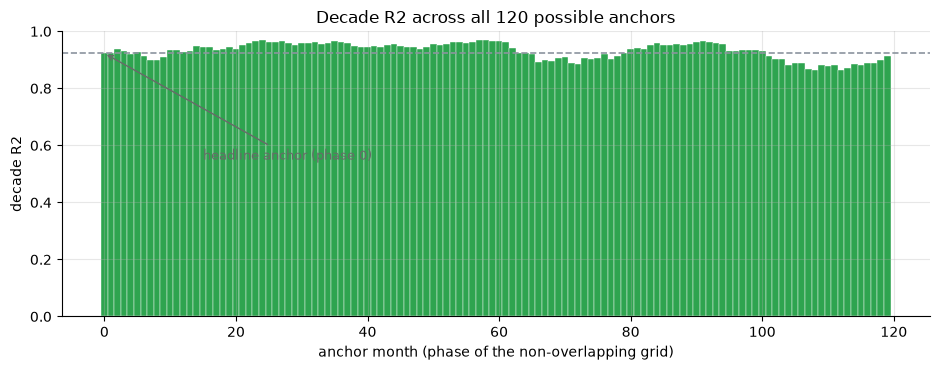

In [4]:
if HAVE_REAL:
    ps = st.phase_sweep(PANEL)
    print(f"R2 min/med/max = {ps['r2_min']:.3f} / {ps['r2_med']:.3f} / {ps['r2_max']:.3f}"
          f"  | slope-t min/med = {ps['t_min']:+.2f} / {ps['t_med']:+.2f}"
          f"  ({ps['n_phases']} phases, n = {ps['n_min']}-{ps['n_max']})")
    r2s = [st.decade_ols(PANEL, phase=ph)['r2'] for ph in range(120)]
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    ax.bar(range(120), r2s, color=GREEN, width=1.0, edgecolor='white', linewidth=0.3)
    ax.axhline(R['r2'], color=GREY, ls='--', lw=1.2)
    ax.annotate('headline anchor (phase 0)', xy=(0, R['r2']), xytext=(15, 0.55),
                fontsize=9, color='dimgray', arrowprops=dict(arrowstyle='->', color='dimgray'))
    ax.set_xlabel('anchor month (phase of the non-overlapping grid)')
    ax.set_ylabel('decade R2'); ax.set_ylim(0, 1)
    ax.set_title('Decade R2 across all 120 possible anchors')
    plt.tight_layout(); plt.show()
else:
    print('frozen: R2 min/med/max', R['ph_r2_min'], R['ph_r2_med'], R['ph_r2_max'])

The *worst* of the 120 anchors gives R² = 0.865 and slope t = +8.8. No cherry-picked phase.

## 3 · Secondary — overlapping windows with NW(120) HAC

In [5]:
if HAVE_REAL:
    h = st.overlapping_hac(PANEL, lags=120)
    print(f"n = {h['n']:,} overlapping windows | R2 = {h['r2']:.3f} | "
          f"slope = {h['slope']:+.3f} | HAC t = {h['hac_t_slope']:+.2f} (lags={h['lags']})")
else:
    print('frozen: HAC t', R['hac_t'], 'R2', R['hac_r2'])

n = 1,746 overlapping windows | R2 = 0.916 | slope = +1.140 | HAC t = +32.71 (lags=120)


> 💡 **In plain words.** Using every month as a decade-start creates windows that share up to 119 of their 120 months — classic pseudo-replication (Valkanov 2003). The Newey-West correction with 120 lags eats that; the slope still stands at t = **+32.7**. It's secondary; the honest unit is the decade above.

## 4 · Sub-periods, the 2020 cohort, and the nominal-vs-real collapse

In [6]:
if HAVE_REAL:
    usable = PANEL.dropna(subset=['fwd10'])
    half = usable.index[len(usable)//2]
    for name, sub in [('first half ', PANEL.loc[:half]), ('second half', PANEL.loc[half:])]:
        s = st.decade_ols(sub, phase=0)
        print(f"{name}: {s['starts'][0]}..{s['starts'][-1]}  n={s['n']}  "
              f"R2={s['r2']:.3f}  slope={s['slope']:+.2f} (t={s['t_slope']:+.2f})")
    c = st.cohort_autopsy(PANEL, start='2020-12-01')
    print(f"\n2020 cohort (PARTIAL decade): start {c['start']} at {c['start_yield']*100:.2f}% | "
          f"{c['years_elapsed']:.1f}y realised {c['realized_ann']*100:+.2f}%/yr | "
          f"max DD {c['max_drawdown']*100:.1f}% | needs {c['required_rest_ann']*100:+.2f}%/yr to land")
    rp = data.load_bond_panel_real()
    dr = st.decade_ols(rp, xcol='gs10', ycol='fwd10_real', phase=0)
    print(f"\nnominal yield vs REAL fwd decade: n={dr['n']}  R2={dr['r2']:.3f}  "
          f"slope={dr['slope']:+.2f} (t={dr['t_slope']:+.2f})  <- the lock is nominal only")
else:
    print('frozen: halves', R['halves'], '| cohort', R['c_realized'], '| real R2', R['rr_r2'])

first half : 1871-01..1941-01  n=8  R2=0.908  slope=+1.20 (t=+7.69)
second half: 1943-10..2013-10  n=8  R2=0.954  slope=+1.30 (t=+11.17)

2020 cohort (PARTIAL decade): start 2020-12 at 0.93% | 5.5y realised -2.21%/yr | max DD -22.9% | needs +4.91%/yr to land

nominal yield vs REAL fwd decade: n=15  R2=0.239  slope=+0.81 (t=+2.02)  <- the lock is nominal only


Both halves hold on their own (R² 0.908 and 0.954) — gold standard and fiat alike. The 2020 cohort is the identity *in progress*: -2.21%/yr realised after the 2022 crash, with the remaining-years requirement (+4.91%/yr) sitting right where post-crash yields are — mean reversion toward the ticket price, exactly as duration targeting predicts.

**The honesty check:** against CPI-deflated returns R² collapses to **0.239** (slope t = +2.02). The starting yield pins dollars, not purchasing power — named on the Tradability axis.

## 5 · Third axis — the same design on stocks

In [7]:
if HAVE_REAL:
    stk = data.load_stock_decades()
    sd = st.decade_ols(stk, xcol='ey', ycol='fwd10', phase=0)
    sh = st.overlapping_hac(stk, xcol='ey', ycol='fwd10', lags=120)
    print(f"stocks (1/CAPE vs fwd 10y nominal TR): n={sd['n']} decades "
          f"({sd['starts'][0]}..{sd['starts'][-1]})")
    print(f"  R2 = {sd['r2']:.3f}  slope = {sd['slope']:+.2f} (t = {sd['t_slope']:+.2f})  "
          f"MAE = {sd['mae_identity']*100:.2f} pp/yr")
    print(f"  overlapping: R2 = {sh['r2']:.3f}  HAC t = {sh['hac_t_slope']:+.2f} (n={sh['n']:,})")
    print(f"  vs bonds: R2 {R['r2']} and MAE {R['mae_pp']} pp/yr on the identical design")
else:
    print('frozen: stocks R2', R['s_r2'], 't', R['s_t'])

stocks (1/CAPE vs fwd 10y nominal TR): n=14 decades (1881-01..2011-01)
  R2 = 0.205  slope = +0.63 (t = +1.76)  MAE = 4.57 pp/yr
  overlapping: R2 = 0.251  HAC t = +3.48 (n=1,590)
  vs bonds: R2 0.923 and MAE 0.64 pp/yr on the identical design


Decade-unit t = **1.76** — *below* the bar that bonds clear at +12.5. The overlapping HAC t (+3.48) says there is *some* long-horizon signal in valuations (that is exactly [study 120](../../120-excess-cape-yield/README.md)'s territory, where the bond-adjusted ECY reaches R² 0.70 on excess returns) — but nothing like an identity. **Busted** as a transfer of *this* claim.

## 6 · Tradability arithmetic

In [8]:
spread_bp = R['spread_bp']
drag = spread_bp / 10
print(f'one entry per decade: TreasuryDirect $0 commission; ~{spread_bp:.0f} bp one-way spread')
print(f'amortised drag = {drag:.2f} bp/yr vs forecast MAE {R["mae_pp"]} pp/yr '
      f'(~{R["cost_ratio"]}x larger) | capacity > $25T | long-only, no borrow')

one entry per decade: TreasuryDirect $0 commission; ~2 bp one-way spread
amortised drag = 0.20 bp/yr vs forecast MAE 0.64 pp/yr (~319x larger) | capacity > $25T | long-only, no borrow


> 💡 **In plain words.** There is nothing to "trade": you buy one bond (or a constant-maturity fund) and the arithmetic does the rest. Costs are three orders of magnitude below the forecast error. What you *cannot* buy with it is protection from inflation, or any edge over the next person — the yield is public.

## 7 · Synthetic control — machinery proof (never market evidence)

A seeded AR(1) yield path drives the **same** pricing engine; `link` blends mechanical returns with yield-independent noise. Planted world (`link=1`) must light up; the null (`link=0`) must not. **Nulls are seed-averaged (20 seeds)** — single-seed nulls are banned on this desk.

In [9]:
for link in (1.0, 0.5, 0.0):
    r2s, ts = [], []
    for seed in range(625, 645):
        frame, truth = data.synthetic_world(link=link, seed=seed)
        s = st.decade_ols(frame, phase=0)
        r2s.append(s['r2']); ts.append(s['t_slope'])
    r2s, ts = np.array(r2s), np.array(ts)
    print(f'link={link:.1f}: mean R2 = {r2s.mean():.3f}  mean t = {ts.mean():+.2f}  '
          f'share |t|>=2 = {(np.abs(ts)>=2).mean()*100:.0f}%  (20 seeds, n=14 decades)')

link=1.0: mean R2 = 0.900  mean t = +11.20  share |t|>=2 = 100%  (20 seeds, n=14 decades)


link=0.5: mean R2 = 0.729  mean t = +6.65  share |t|>=2 = 95%  (20 seeds, n=14 decades)


link=0.0: mean R2 = 0.102  mean t = +0.20  share |t|>=2 = 10%  (20 seeds, n=14 decades)


The engine banks the planted identity (mean R² 0.90 at `link=1`) and rejects at ≈ the nominal 10% rate in the null — the real-tape R² 0.92 is measurement, not construction. *(A machinery proof only.)*

## Verdict

- **Signal — REAL.** R² = 0.923, slope t = +12.5 on 15 non-overlapping decades; worst-phase R² 0.865 / t +8.8; HAC t +32.7 on overlapping windows; slope ≈ 1, intercept ≈ 0; both century-halves hold. Caveat: one country's never-defaulted tape.
- **Tradability — INVESTABLE.** 0.2 bp/yr amortised cost, >$25T capacity, $0 retail access. You deploy a *known nominal decade* — beta, not alpha; the real-return R² is only 0.239.
- **Works for stocks? — BUSTED.** R² 0.205, decade t 1.76 < 2, MAE 4.57 pp/yr. The stock-side repair is [study 120's ECY](../../120-excess-cape-yield/README.md).

*Reproducible run: [docs/results.md](../docs/results.md) · literature: [docs/references.md](../docs/references.md) · not investment advice.*